## 1. Configuration — c'est ici, et seulement ici, qu'il faut modifier quelque chose

**`LACS`** — un dictionnaire avec un lac par entrée : `"Nom du lac": {"fichiers": [...], "taux_echantillonnage": ...}`.

- `"fichiers"` : la ou les CSV de ce lac. S'il y a plusieurs caméras sur le même lac, on met plusieurs fichiers dans la liste — leurs comptages seront combinés automatiquement (voir section 2 pour le détail de comment).
- `"taux_echantillonnage"` : la part de la zone du lac que les caméras couvrent réellement, entre 0 et 1. Si on estime par exemple qu'elles ne voient que la moitié de la zone où des baigneurs peuvent se trouver, on met `0.5` — tous les comptages de ce lac seront alors doublés pour estimer le total réel. Mettre `1` quand la caméra couvre toute la zone ou que l'on ne veut pas utiliser ce paramètre.
- On peut ajouter autant de lacs qu'on veut, sur ce modèle.
- Le chemin d'un fichier peut être relatif (s'il est dans le même dossier que ce notebook) ou complet.

**`DATE_DEBUT` / `DATE_FIN`** — la période à analyser, au format `"AAAA-MM-JJ"`.

**`SEUIL_MODERE` / `SEUIL_FORT`** — les deux seuils qui découpent la fréquentation de chaque lac en trois niveaux (faible / modérée / forte), utilisés dans les tableaux et graphiques de la section 5. Ils sont exprimés en % d'une échelle propre à chaque lac (normalisée entre son minimum et son maximum observés — voir section 4bis pour l'explication).


In [1]:
LACS = {
    "Lac du Lauvitel": {
        "fichiers": ["CAIRN_Lauvitel_2025.csv"],
        "taux_echantillonnage": 1,
    },
    "Lac du Lauzon": {
        "fichiers": ["CAIRN_Lauzon_2025.csv"],
        "taux_echantillonnage": 1,
    },
    "Lac de la Muzelle": {
        "fichiers": ["CAIRN_Muzelle_2025.csv"],
        "taux_echantillonnage": 1,
    },
    # Ajoutez autant de lacs que nécessaire, sur le même modèle :
    # "Nom du lac": {"fichiers": ["chemin/fichier1.csv", "chemin/fichier2.csv"], "taux_echantillonnage": 0.5},
}

DATE_DEBUT = "2025-07-01"
DATE_FIN   = "2025-08-31"

# Seuils (en % du maximum observé sur son propre lac) définissant les 3 niveaux de fréquentation
SEUIL_MODERE = 30
SEUIL_FORT   = 60

## 2. Chargement et préparation des données

Rien à toucher ici, c'est la partie qui lit les CSV et prépare les calculs pour la suite. Deux règles méritent d'être explicitées, parce qu'elles conditionnent tous les chiffres qui suivent :

**Plusieurs photos dans la même heure, sur une même caméra.** Ça arrive, et dans ce cas on ne les additionne surtout pas (ce serait compter les mêmes baigneurs plusieurs fois) : on garde le maximum observé sur cette heure. En revanche, si un lac a deux caméras différentes, leurs comptages sont bien additionnés, puisqu'elles regardent des zones différentes.

**Le nombre de baigneurs par jour.** Contrairement aux tentes, on prend ici la journée calendaire (minuit à minuit), et on **additionne** tous les comptages horaires de la journée plutôt que de garder un pic : un baigneur compté à 10h et un baigneur compté à 16h correspondent à deux passages différents (pas à la même personne restée sur place), donc on les somme plutôt que d'en garder le maximum.


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, FileLink

EXPORT_DIR = "exports"
os.makedirs(EXPORT_DIR, exist_ok=True)

def exporter_graphique(fig, nom, df_data=None):
    """Sauvegarde le graphique en PDF (et les données en CSV si fournies) et affiche des liens de téléchargement."""
    chemin_pdf = os.path.join(EXPORT_DIR, f"{nom}.pdf")
    fig.savefig(chemin_pdf, bbox_inches="tight")
    display(FileLink(chemin_pdf, result_html_prefix="📄 Télécharger le graphique en PDF : "))
    if df_data is not None:
        chemin_csv = os.path.join(EXPORT_DIR, f"{nom}.csv")
        df_data.to_csv(chemin_csv)
        display(FileLink(chemin_csv, result_html_prefix="📊 Télécharger les données en CSV : "))

def exporter_tableau(df, nom):
    """Sauvegarde un tableau en CSV et affiche un lien de téléchargement."""
    chemin_csv = os.path.join(EXPORT_DIR, f"{nom}.csv")
    df.to_csv(chemin_csv)
    display(FileLink(chemin_csv, result_html_prefix="📊 Télécharger le tableau en CSV : "))

def colorer_weekends(ax, dates, max_ticks=10):
    """Sur un axe dont x représente des dates : grise en rose pâle les périodes de week-end
    (samedi+dimanche fusionnés en une seule bande), et affiche des graduations de dates simples
    et régulièrement espacées (indépendamment des week-ends). C'est ce fond teinté qui rend les
    week-ends visibles, pas les graduations — donc ça marche aussi bien sur 10 jours que sur 3 mois."""
    dates = pd.to_datetime(sorted(pd.unique(dates)))
    if len(dates) == 0:
        return
    i = 0
    while i < len(dates):
        if dates[i].weekday() >= 5:
            j = i
            while j + 1 < len(dates) and dates[j + 1].weekday() >= 5 and (dates[j + 1] - dates[j]).days == 1:
                j += 1
            ax.axvspan(dates[i] - pd.Timedelta(hours=12), dates[j] + pd.Timedelta(hours=12),
                       color="tab:red", alpha=0.12, zorder=0)
            i = j + 1
        else:
            i += 1
    pas = max(1, len(dates) // max_ticks)
    ticks = dates[::pas]
    ax.set_xticks(ticks)
    ax.set_xticklabels([d.strftime("%d/%m") for d in ticks], rotation=45, ha="right")
    ax.set_xlim(dates.min() - pd.Timedelta(hours=12), dates.max() + pd.Timedelta(hours=12))

def colorer_weekends_heatmap(ax, colonnes_dates, n_lignes, max_ticks=15):
    """Équivalent de colorer_weekends pour une heatmap (axe x en indices de colonnes, pas en dates) :
    entoure d'un contour noir chaque bloc de colonnes de week-end (visible quelle que soit la couleur
    de fond en dessous), et affiche des graduations régulières."""
    import matplotlib.patches as mpatches
    n = len(colonnes_dates)
    i = 0
    while i < n:
        if colonnes_dates[i].weekday() >= 5:
            j = i
            while j + 1 < n and colonnes_dates[j + 1].weekday() >= 5:
                j += 1
            ax.add_patch(mpatches.Rectangle(
                (i - 0.5, -0.5), j - i + 1, n_lignes,
                fill=False, edgecolor="black", linewidth=1.6, zorder=3,
            ))
            i = j + 1
        else:
            i += 1
    pas = max(1, n // max_ticks)
    ax.set_xticks(range(0, n, pas))
    ax.set_xticklabels([colonnes_dates[i].strftime("%d/%m") for i in range(0, n, pas)], rotation=45, ha="right")

COUNT_COLS = ["count_baigneur"]

def charger_lac(nom_lac, fichiers_csv, taux_echantillonnage):
    dfs = []
    for f in fichiers_csv:
        d = pd.read_csv(f)
        d["source_fichier"] = f  # identifie la caméra d'origine (1 fichier = 1 caméra)
        dfs.append(d)
    df = pd.concat(dfs, ignore_index=True)
    df["lac"] = nom_lac
    df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=df["day"]))
    # On "remonte" les comptages en fonction de la couverture réelle des caméras :
    # si le taux est de 0.5 (caméras qui ne voient que 50% de la zone), on double les comptages observés.
    for col in COUNT_COLS:
        df[col] = df[col] / taux_echantillonnage
    return df

# Chargement de tous les lacs (en appliquant le taux d'échantillonnage de chacun)
_dfs = []
_taux_lacs = {}
for nom_lac, config_lac in LACS.items():
    taux = config_lac.get("taux_echantillonnage", 1)
    _taux_lacs[nom_lac] = taux
    _dfs.append(charger_lac(nom_lac, config_lac["fichiers"], taux))
donnees = pd.concat(_dfs, ignore_index=True)

# Filtrage sur la période choisie
date_debut = pd.to_datetime(DATE_DEBUT)
date_fin   = pd.to_datetime(DATE_FIN)
donnees = donnees[(donnees["date"] >= date_debut) & (donnees["date"] <= date_fin)]

print(f"Période analysée : {date_debut.date()} → {date_fin.date()}")
print(f"Lacs et taux d'échantillonnage appliqués : {_taux_lacs}")
print(f"{len(donnees)} lignes chargées.")

# Agrégation horaire en 2 temps :
# 1) Sur une même caméra (même fichier CSV), plusieurs images peuvent tomber dans la même heure : on prend le MAX
#    (ce sont les mêmes baigneurs vus plusieurs fois, pas des baigneurs différents à additionner).
# 2) Entre caméras différentes d'un même lac, on SOMME (elles couvrent des zones différentes du lac).
horaire_par_camera = (
    donnees
    .groupby(["lac", "source_fichier", "date", "hour"], as_index=False)[COUNT_COLS]
    .max()
)
horaire = (
    horaire_par_camera
    .groupby(["lac", "date", "hour"], as_index=False)[COUNT_COLS]
    .sum()
    .sort_values(["lac", "date", "hour"])
)

# Comptage journalier de baigneurs = somme sur toutes les heures de la journée calendaire (minuit-minuit).
# Contrairement aux tentes, on additionne (et on ne garde pas le pic) : un baigneur vu à 10h et un autre
# vu à 16h sont deux passages différents, pas la même personne restée sur place.
journalier = (
    horaire
    .groupby(["lac", "date"], as_index=False)[COUNT_COLS]
    .sum()
)
journalier["jour_semaine"] = journalier["date"].dt.weekday  # 0=lundi ... 6=dimanche
journalier["week_end"] = journalier["jour_semaine"] >= 5

# Liste des lacs (dans l'ordre de LACS), utilisée pour tous les graphiques "un sous-graphique par lac"
lacs_liste = list(LACS.keys())
n = len(lacs_liste)

# Référence commune de dates (toute la période, tous lacs confondus) : utilisée pour que les graphiques
# 1 et 1bis partagent exactement les mêmes graduations et la même plage sur l'axe des dates,
# ce qui les rend directement comparables entre eux.
dates_communes = pd.Series(sorted(journalier["date"].unique()))

journalier.head()


Période analysée : 2025-07-01 → 2025-08-31
Lacs et taux d'échantillonnage appliqués : {'Lac du Lauvitel': 1, 'Lac du Lauzon': 1, 'Lac de la Muzelle': 1}
3711 lignes chargées.


,lac,date,count_baigneur,jour_semaine,week_end
0,Lac de la Muzelle,2025-07-03,0.0,3,False
1,Lac de la Muzelle,2025-07-04,0.0,4,False
2,Lac de la Muzelle,2025-07-05,0.0,5,True
3,Lac de la Muzelle,2025-07-06,0.0,6,True
4,Lac de la Muzelle,2025-07-07,0.0,0,False


## 3. Tableau récapitulatif

Pour chaque lac : la moyenne journalière, la moyenne en semaine, la moyenne le week-end, et le jour de pointe avec sa valeur. De quoi avoir une vue d'ensemble avant de rentrer dans le détail des graphiques.


In [3]:
def tableau_recap(journalier_df, colonne, libelle):
    lignes = {}
    for lac, grp in journalier_df.groupby("lac"):
        moyenne = grp[colonne].mean()
        moyenne_ouvre = grp.loc[~grp["week_end"], colonne].mean()
        moyenne_we = grp.loc[grp["week_end"], colonne].mean()
        idx_pic = grp[colonne].idxmax()
        jour_pic = grp.loc[idx_pic, "date"].date()
        valeur_pic = grp.loc[idx_pic, colonne]
        lignes[lac] = {
            "Moyenne journalière": round(moyenne, 1),
            "Moyenne jours ouvrés": round(moyenne_ouvre, 1),
            "Moyenne week-end": round(moyenne_we, 1),
            "Jour de pointe": jour_pic,
            "Valeur au jour de pointe": valeur_pic,
        }
    tableau = pd.DataFrame(lignes)
    print(f"\n=== {libelle} ===")
    display(tableau)
    exporter_tableau(tableau, f"tableau_recap_{libelle.lower()}")
    return tableau

_ = tableau_recap(journalier, "count_baigneur", "Baigneurs")



=== Baigneurs ===


,Lac de la Muzelle,Lac du Lauvitel,Lac du Lauzon
Moyenne journalière,0.3,8.7,0.1
Moyenne jours ouvrés,0.3,8.7,0.2
Moyenne week-end,0.2,8.7,0.0
Jour de pointe,2025-08-08,2025-07-12,2025-08-05
Valeur au jour de pointe,4.0,41.0,3.0


/home/lweksteen/CrowdShore/exports/tableau_recap_baigneurs.csv

## 3bis. Tableau détaillé, jour par jour

Les lacs en colonnes, les jours en lignes — pratique pour retrouver une valeur précise, ou pour exporter les données brutes.


In [4]:
tableau_journalier_baigneurs = journalier.pivot(index="date", columns="lac", values="count_baigneur")
display(tableau_journalier_baigneurs)
exporter_tableau(tableau_journalier_baigneurs, "tableau_journalier_baigneurs")


lac,Lac de la Muzelle,Lac du Lauvitel,Lac du Lauzon
date,,,
2025-07-01,NaN,13.0,NaN
2025-07-02,NaN,5.0,NaN
2025-07-03,0.0,4.0,NaN
2025-07-04,0.0,10.0,NaN
2025-07-05,0.0,12.0,NaN
...,...,...,...
2025-08-27,0.0,0.0,0.0
2025-08-28,0.0,1.0,0.0
2025-08-29,0.0,0.0,0.0


/home/lweksteen/CrowdShore/exports/tableau_journalier_baigneurs.csv

## 4. Graphique 1 — nombre de baigneurs par jour


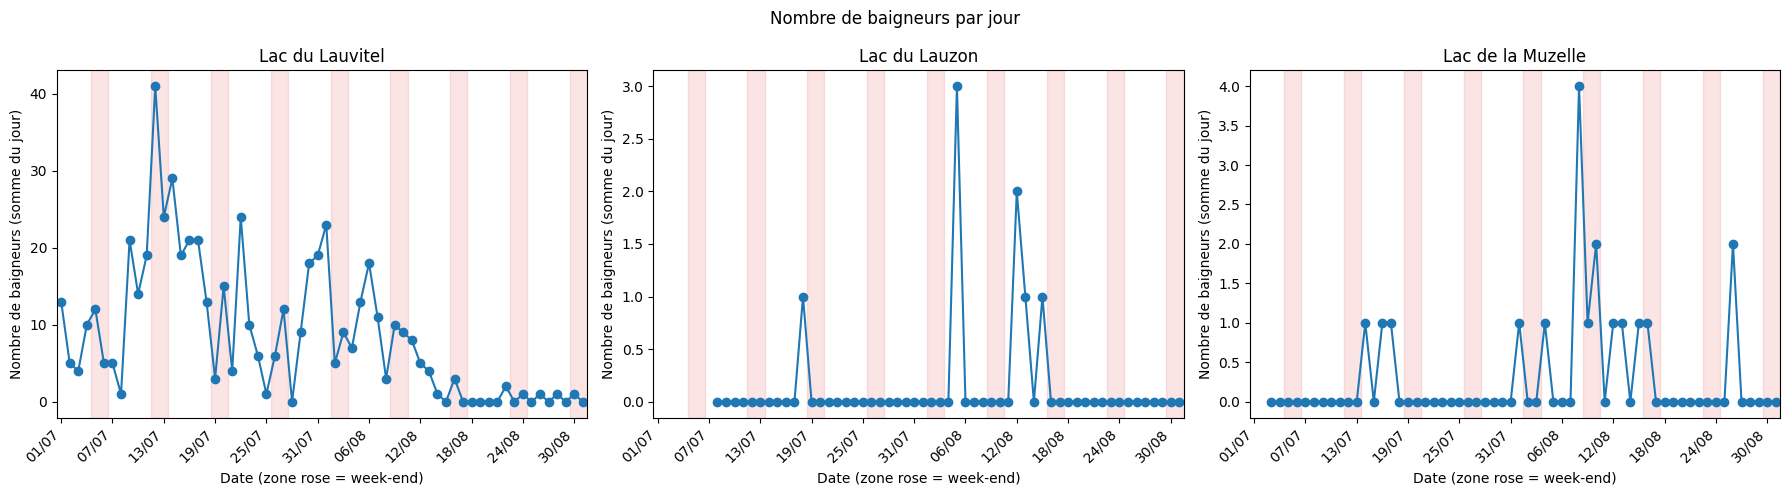

/home/lweksteen/CrowdShore/exports/graphique1_baigneurs_par_jour.pdf

/home/lweksteen/CrowdShore/exports/graphique1_baigneurs_par_jour.csv

In [5]:
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), squeeze=False)
axes = axes[0]
for ax, lac in zip(axes, lacs_liste):
    grp = journalier[journalier["lac"] == lac].sort_values("date")
    ax.plot(grp["date"], grp["count_baigneur"], marker="o", color="tab:blue")
    ax.set_xlabel("Date (zone rose = week-end)")
    ax.set_ylabel("Nombre de baigneurs (somme du jour)")
    ax.set_title(lac)
    colorer_weekends(ax, dates_communes)
fig.suptitle("Nombre de baigneurs par jour")
plt.tight_layout()
plt.show()
exporter_graphique(fig, "graphique1_baigneurs_par_jour", journalier[["lac", "date", "count_baigneur"]])


## 4bis. Graphique 1bis — fréquentation normalisée

Les comptages ne sont pas exhaustifs : les caméras échantillonnent, elles ne voient pas forcément tous les baigneurs du lac. Comparer les lacs entre eux sur des valeurs absolues n'a donc pas vraiment de sens si leur couverture caméra diffère.

Ce graphique normalise chaque lac par rapport à lui-même : pour chaque jour, on situe le nombre de baigneurs entre le minimum et le maximum observés sur la période *pour ce lac* (`(valeur - min) / (max - min) × 100`). Un jour à 0 % correspond au jour le plus calme du lac, un jour à 100 % à son jour de pointe. Ça permet de comparer la dynamique de fréquentation entre lacs — qui monte, qui redescend, quand — indépendamment de leur niveau d'échantillonnage. Le minimum et le maximum utilisés comme repères sont indiqués dans le titre de chaque sous-graphique.


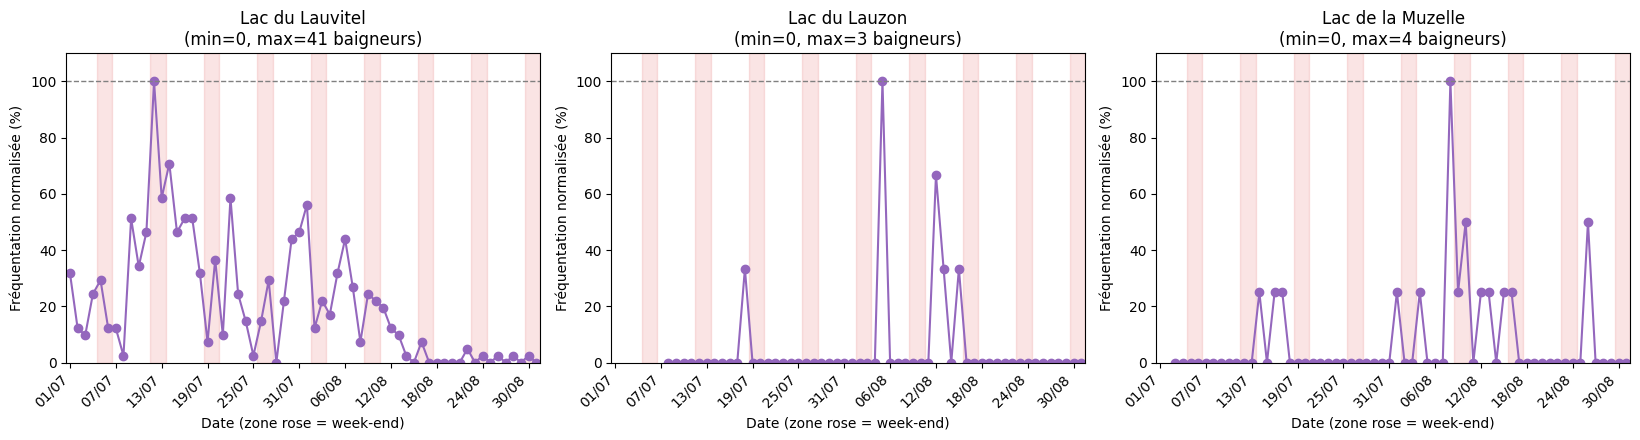

/home/lweksteen/CrowdShore/exports/graphique1bis_frequentation_relative.pdf

/home/lweksteen/CrowdShore/exports/graphique1bis_frequentation_relative.csv

In [6]:
fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 4.5), squeeze=False)
axes = axes[0]
normalise_lignes = []
for ax, lac in zip(axes, lacs_liste):
    grp = journalier[journalier["lac"] == lac].sort_values("date")
    min_lac = grp["count_baigneur"].min()
    max_lac = grp["count_baigneur"].max()
    etendue = max_lac - min_lac
    pct = (grp["count_baigneur"] - min_lac) / etendue * 100 if etendue > 0 else grp["count_baigneur"] * 0
    ax.plot(grp["date"], pct, marker="o", color="tab:purple")
    ax.axhline(100, color="grey", linestyle="--", linewidth=1)
    ax.set_title(f"{lac}\n(min={round(min_lac)}, max={round(max_lac)} baigneurs)")
    ax.set_xlabel("Date (zone rose = week-end)")
    ax.set_ylabel("Fréquentation normalisée (%)")
    ax.set_ylim(0, 110)
    colorer_weekends(ax, dates_communes)
    normalise_lignes.append(
        grp.assign(pct_normalise=pct, min_observe=min_lac, max_observe=max_lac)[["lac", "date", "count_baigneur", "min_observe", "max_observe", "pct_normalise"]]
    )
plt.tight_layout()
plt.show()
exporter_graphique(fig, "graphique1bis_frequentation_relative", pd.concat(normalise_lignes, ignore_index=True))


## 5. Trois niveaux de fréquentation, par lac

Sur la base de cette même échelle normalisée (min-max, propre à chaque lac), on classe chaque jour en trois niveaux :

- **Faible** : en dessous de `SEUIL_MODERE` % de l'échelle du lac,
- **Modérée** : entre `SEUIL_MODERE` % et `SEUIL_FORT` %,
- **Forte** : à partir de `SEUIL_FORT` %.

Ces seuils se modifient dans la cellule de configuration (section 1).


In [7]:
def classer_niveau(pct):
    if pct >= SEUIL_FORT:
        return "Forte"
    elif pct >= SEUIL_MODERE:
        return "Modérée"
    else:
        return "Faible"

NIVEAUX_ORDRE = ["Faible", "Modérée", "Forte"]

journalier_niveaux = journalier.copy()
journalier_niveaux["min_lac"] = journalier_niveaux.groupby("lac")["count_baigneur"].transform("min")
journalier_niveaux["max_lac"] = journalier_niveaux.groupby("lac")["count_baigneur"].transform("max")
journalier_niveaux["pct_du_max"] = np.where(
    journalier_niveaux["max_lac"] > journalier_niveaux["min_lac"],
    (journalier_niveaux["count_baigneur"] - journalier_niveaux["min_lac"])
    / (journalier_niveaux["max_lac"] - journalier_niveaux["min_lac"]) * 100,
    0,
)
journalier_niveaux["niveau"] = journalier_niveaux["pct_du_max"].apply(classer_niveau)
journalier_niveaux["niveau"] = pd.Categorical(journalier_niveaux["niveau"], categories=NIVEAUX_ORDRE, ordered=True)

# Tableau récap : nombre (et %) de jours par niveau, pour chaque lac
tableau_niveaux = (
    journalier_niveaux.groupby(["lac", "niveau"]).size().unstack("niveau", fill_value=0).reindex(columns=NIVEAUX_ORDRE)
)
tableau_niveaux_pct = tableau_niveaux.div(tableau_niveaux.sum(axis=1), axis=0) * 100
tableau_niveaux_pct = tableau_niveaux_pct.round(1)

print("=== Nombre de jours par niveau de fréquentation ===")
display(tableau_niveaux)
exporter_tableau(tableau_niveaux, "tableau_jours_par_niveau")

print("\n=== % de jours par niveau de fréquentation ===")
display(tableau_niveaux_pct)
exporter_tableau(tableau_niveaux_pct, "tableau_pct_jours_par_niveau")


=== Nombre de jours par niveau de fréquentation ===


/tmp/ipykernel_985602/1148777276.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  journalier_niveaux.groupby(["lac", "niveau"]).size().unstack("niveau", fill_value=0).reindex(columns=NIVEAUX_ORDRE)


niveau,Faible,Modérée,Forte
lac,,,
Lac de la Muzelle,57,2,1
Lac du Lauvitel,44,16,2
Lac du Lauzon,50,3,2


/home/lweksteen/CrowdShore/exports/tableau_jours_par_niveau.csv


=== % de jours par niveau de fréquentation ===


niveau,Faible,Modérée,Forte
lac,,,
Lac de la Muzelle,95.0,3.3,1.7
Lac du Lauvitel,71.0,25.8,3.2
Lac du Lauzon,90.9,5.5,3.6


/home/lweksteen/CrowdShore/exports/tableau_pct_jours_par_niveau.csv

## 6. Heatmap calendrier — niveaux de fréquentation

Une ligne par lac, une colonne par jour, la couleur donne le niveau (jaune pâle = faible, orange = modérée, rouge = forte). C'est le format le plus rapide pour repérer d'un coup d'œil les week-ends qui ressortent, une période de vacances plus chargée, ou une tendance qui se dessine sur la saison. Les jours de week-end sont en plus signalés par une marque rouge sous la colonne correspondante.


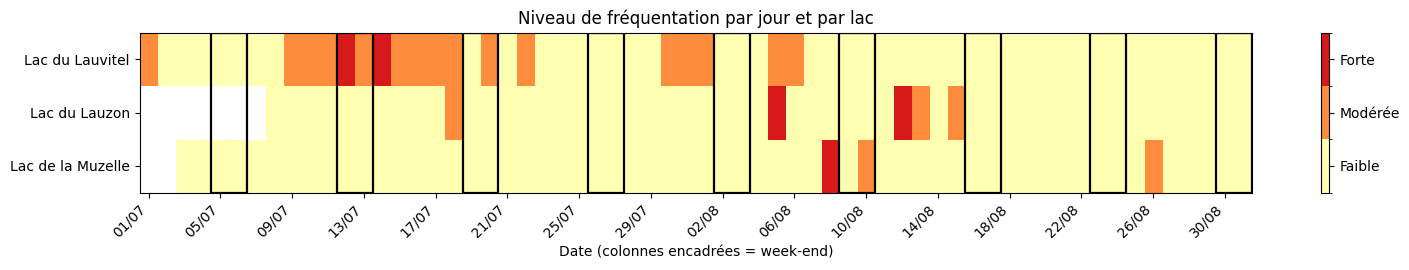

/home/lweksteen/CrowdShore/exports/graphique_heatmap_niveaux.pdf

/home/lweksteen/CrowdShore/exports/graphique_heatmap_niveaux.csv

In [8]:
niveau_code = {"Faible": 0, "Modérée": 1, "Forte": 2}
heatmap_data = (
    journalier_niveaux.assign(niveau_num=journalier_niveaux["niveau"].map(niveau_code))
    .pivot(index="lac", columns="date", values="niveau_num")
    .reindex(lacs_liste)
    .astype(float)
)

from matplotlib.colors import ListedColormap, BoundaryNorm
cmap = ListedColormap(["#ffffb2", "#fd8d3c", "#d7191c"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

fig, ax = plt.subplots(figsize=(max(12, 0.25 * heatmap_data.shape[1]), 1 + 0.6 * len(lacs_liste)))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap=cmap, norm=norm)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
colorer_weekends_heatmap(ax, list(heatmap_data.columns), len(lacs_liste))
ax.set_xlabel("Date (colonnes encadrées = week-end)")
ax.set_title("Niveau de fréquentation par jour et par lac")
cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(NIVEAUX_ORDRE)
plt.tight_layout()
plt.show()
exporter_graphique(fig, "graphique_heatmap_niveaux", journalier_niveaux[["lac", "date", "count_baigneur", "pct_du_max", "niveau"]])


## 7. Heatmap calendrier — en dégradé continu

Même heatmap, mais sans découpage en trois niveaux : la couleur suit un dégradé continu, du blanc (0 % de l'échelle normalisée du lac) au violet (100 %). L'intérêt est d'éviter l'effet de seuil de la version précédente, où deux jours très proches (65 % et 67 %, par exemple) pouvaient se retrouver dans deux couleurs franchement différentes. Ici, la progression se lit plus finement.


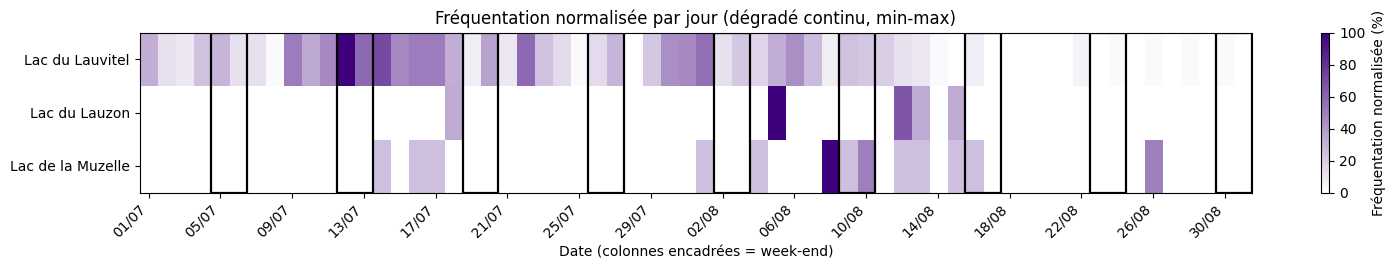

/home/lweksteen/CrowdShore/exports/graphique_heatmap_continue.pdf

/home/lweksteen/CrowdShore/exports/graphique_heatmap_continue.csv

In [9]:
heatmap_continue = (
    journalier_niveaux.pivot(index="lac", columns="date", values="pct_du_max")
    .reindex(lacs_liste)
    .astype(float)
)

from matplotlib.colors import LinearSegmentedColormap
cmap_continu = LinearSegmentedColormap.from_list("blanc_violet", ["#ffffff", "#3f007d"])

fig, ax = plt.subplots(figsize=(max(12, 0.25 * heatmap_continue.shape[1]), 1 + 0.6 * len(lacs_liste)))
im = ax.imshow(heatmap_continue.values, aspect="auto", cmap=cmap_continu, vmin=0, vmax=100)
ax.set_yticks(range(len(heatmap_continue.index)))
ax.set_yticklabels(heatmap_continue.index)
colorer_weekends_heatmap(ax, list(heatmap_continue.columns), len(lacs_liste))
ax.set_xlabel("Date (colonnes encadrées = week-end)")
ax.set_title("Fréquentation normalisée par jour (dégradé continu, min-max)")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Fréquentation normalisée (%)")
plt.tight_layout()
plt.show()
exporter_graphique(fig, "graphique_heatmap_continue", journalier_niveaux[["lac", "date", "count_baigneur", "pct_du_max"]])


## 8. Répartition hebdomadaire des niveaux

Un graphique par lac, avec la part de jours faible / modérée / forte semaine par semaine. Ça permet de voir si un lac monte progressivement en charge au fil de la saison, ou si son niveau de fréquentation reste stable d'une semaine à l'autre.


/tmp/ipykernel_985602/1914467366.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rep = sous.groupby(["semaine", "niveau"]).size().unstack("niveau", fill_value=0).reindex(columns=NIVEAUX_ORDRE, fill_value=0)
/tmp/ipykernel_985602/1914467366.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rep = sous.groupby(["semaine", "niveau"]).size().unstack("niveau", fill_value=0).reindex(columns=NIVEAUX_ORDRE, fill_value=0)
/tmp/ipykernel_985602/1914467366.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current

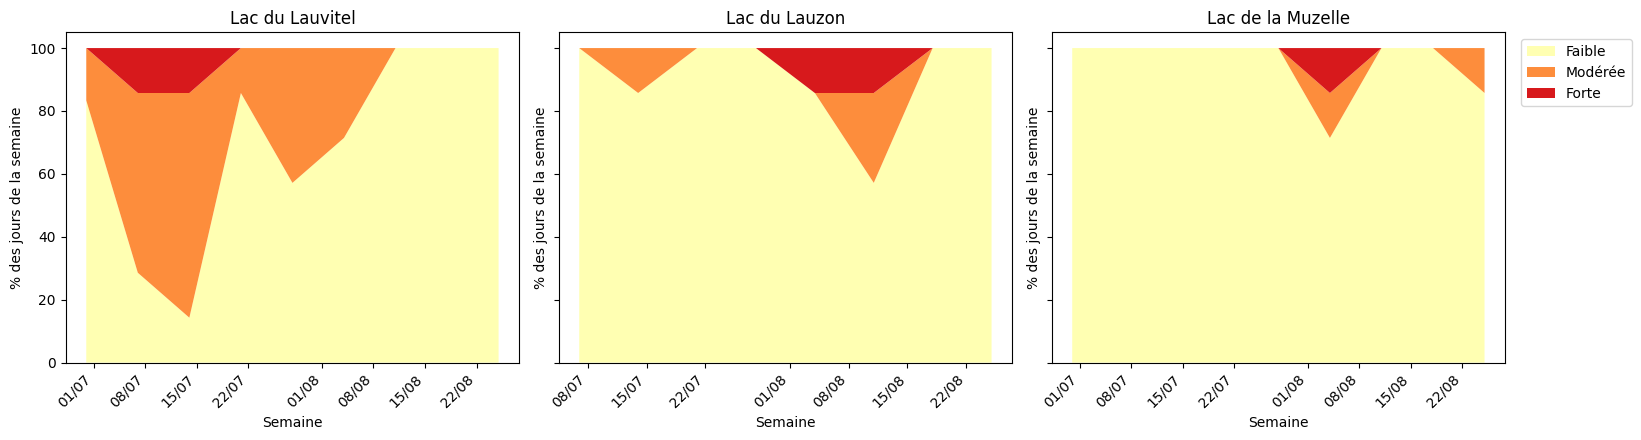

/home/lweksteen/CrowdShore/exports/graphique_repartition_hebdo_niveaux.pdf

/home/lweksteen/CrowdShore/exports/graphique_repartition_hebdo_niveaux.csv

In [10]:
journalier_niveaux["semaine"] = journalier_niveaux["date"].dt.to_period("W").apply(lambda p: p.start_time)

fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 4.5), squeeze=False, sharey=True)
axes = axes[0]
couleurs_niveaux = {"Faible": "#ffffb2", "Modérée": "#fd8d3c", "Forte": "#d7191c"}
for ax, lac in zip(axes, lacs_liste):
    sous = journalier_niveaux[journalier_niveaux["lac"] == lac]
    rep = sous.groupby(["semaine", "niveau"]).size().unstack("niveau", fill_value=0).reindex(columns=NIVEAUX_ORDRE, fill_value=0)
    rep_pct = rep.div(rep.sum(axis=1), axis=0) * 100
    ax.stackplot(
        rep_pct.index, [rep_pct[niv] for niv in NIVEAUX_ORDRE],
        labels=NIVEAUX_ORDRE, colors=[couleurs_niveaux[niv] for niv in NIVEAUX_ORDRE],
    )
    ax.set_title(lac)
    ax.set_xlabel("Semaine")
    ax.set_ylabel("% des jours de la semaine")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()
exporter_graphique(fig, "graphique_repartition_hebdo_niveaux", journalier_niveaux[["lac", "semaine", "niveau"]])


## 9. Comparaison entre lacs — part de jours en forte fréquentation

Les lacs classés selon la part de jours passés en niveau "Forte" sur toute la période. Celui dont la barre est la plus haute est, relativement à son propre maximum, celui qui atteint le plus souvent sa capacité de pointe.


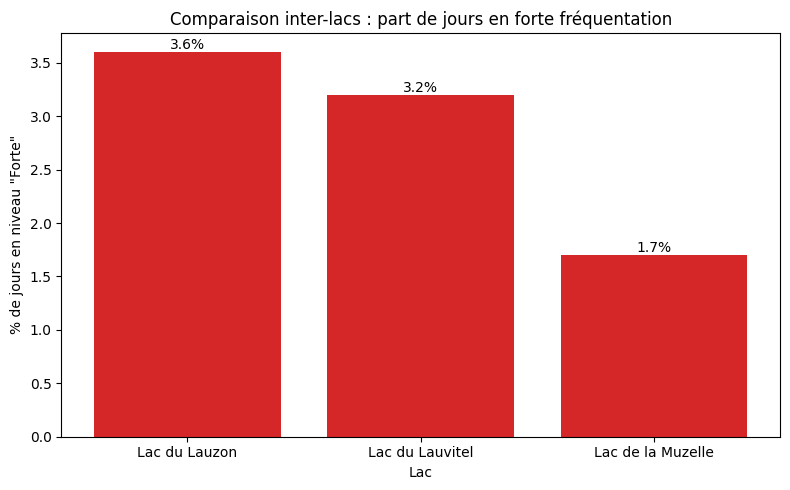

/home/lweksteen/CrowdShore/exports/graphique_comparaison_pct_forte.pdf

/home/lweksteen/CrowdShore/exports/graphique_comparaison_pct_forte.csv

In [11]:
pct_forte = tableau_niveaux_pct["Forte"].reindex(lacs_liste).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(pct_forte.index, pct_forte.values, color="tab:red")
ax.set_xlabel("Lac")
ax.set_ylabel("% de jours en niveau \"Forte\"")
ax.set_title("Comparaison inter-lacs : part de jours en forte fréquentation")
for i, v in enumerate(pct_forte.values):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()
exporter_graphique(fig, "graphique_comparaison_pct_forte", pct_forte.rename("pct_jours_forte").reset_index().rename(columns={"index": "lac"}))


## 10. Graphique 2 — répartition des baigneurs selon les heures de baignade

Pour chaque lac, on additionne le nombre de baigneurs observés à chaque heure, sur toute la période choisie — un histogramme par lac.


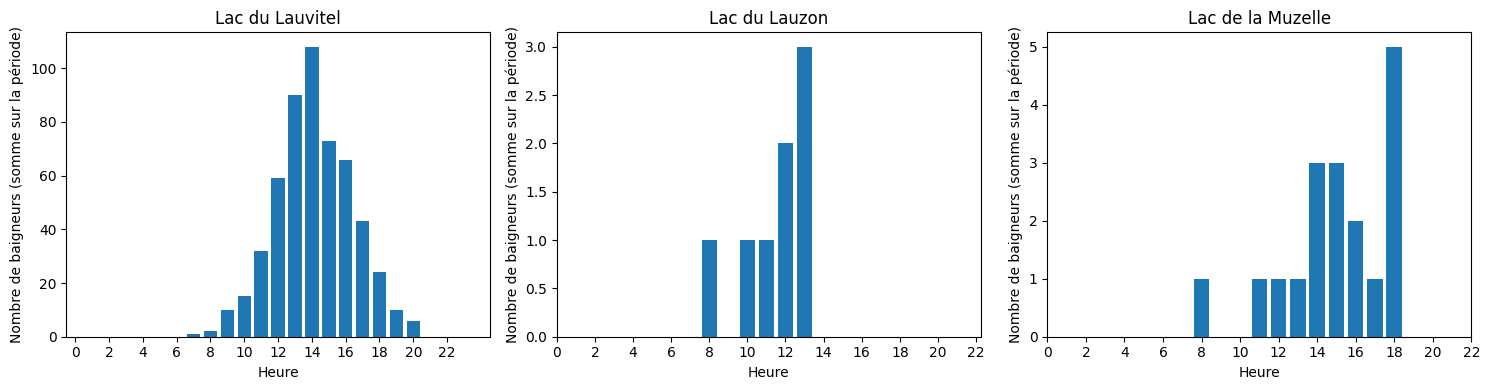

/home/lweksteen/CrowdShore/exports/graphique2_repartition_horaire_baignade.pdf

/home/lweksteen/CrowdShore/exports/graphique2_repartition_horaire_baignade.csv

In [12]:
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)
axes = axes[0]
for ax, lac in zip(axes, lacs_liste):
    sous = horaire[horaire["lac"] == lac]
    repartition = sous.groupby("hour")["count_baigneur"].sum()
    ax.bar(repartition.index, repartition.values, color="tab:blue")
    ax.set_title(lac)
    ax.set_xlabel("Heure")
    ax.set_ylabel("Nombre de baigneurs (somme sur la période)")
    ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()
exporter_graphique(fig, "graphique2_repartition_horaire_baignade", horaire.groupby(["lac", "hour"], as_index=False)["count_baigneur"].sum())


## 11. Graphique 3 — total de baigneurs sur la saison, par lac

La somme, sur toute la période choisie, des comptages journaliers de chaque lac.


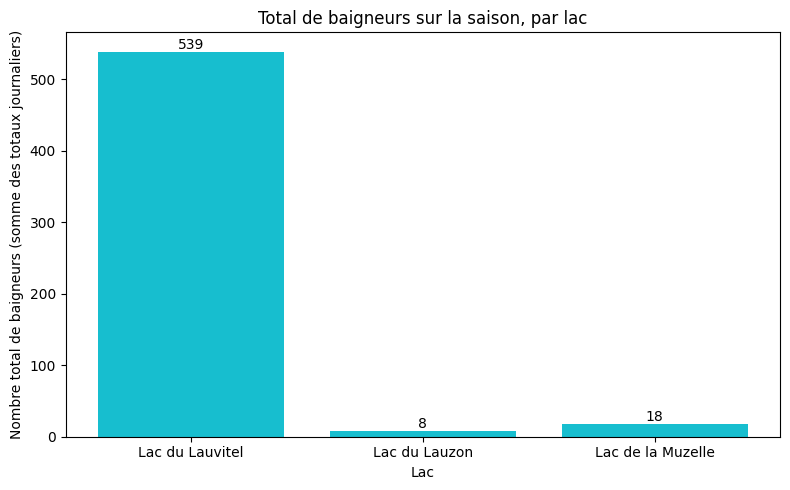

/home/lweksteen/CrowdShore/exports/graphique3_total_saison_baigneurs.pdf

/home/lweksteen/CrowdShore/exports/graphique3_total_saison_baigneurs.csv

In [13]:
total_saison = journalier.groupby("lac")["count_baigneur"].sum().reindex(lacs_liste)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(total_saison.index, total_saison.values, color="tab:cyan")
ax.set_xlabel("Lac")
ax.set_ylabel("Nombre total de baigneurs (somme des totaux journaliers)")
ax.set_title("Total de baigneurs sur la saison, par lac")
for i, v in enumerate(total_saison.values):
    ax.text(i, v, str(round(v)), ha="center", va="bottom")
plt.tight_layout()
plt.show()
exporter_graphique(fig, "graphique3_total_saison_baigneurs", total_saison.reset_index().rename(columns={"count_baigneur": "total_baigneurs_saison"}))
